In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mp
import seaborn as sb
import warnings 
warnings.filterwarnings("ignore")
data = pd.read_csv("C:/Users/braya/Downloads/kc_house_data.csv")
data.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [81]:
correlaciones = data.corr(numeric_only=True)

lista_correlacion = correlaciones['price'].sort_values(ascending=False)

print(lista_correlacion)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64


In [37]:
import statsmodels.api as sm
variables_seleccionadas = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms', 'lat', 'waterfront', 'floors', 'yr_renovated']
X = data[variables_seleccionadas]
y = data['price']
X_report = sm.add_constant(X)
modelo = sm.OLS(y, X_report).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     3841.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:41:17   Log-Likelihood:            -2.9589e+05
No. Observations:               21613   AIC:                         5.918e+05
Df Residuals:                   21601   BIC:                         5.919e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -3.215e+07   5.09e+05    -63.129

In [45]:
#Eliminamos variables como bathrooms ya que su p-value es mayor a 0.05
variables_seleccionadas = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'view', 'sqft_basement', 'bedrooms', 'lat', 'waterfront', 'floors', 'yr_renovated']
X = data[variables_seleccionadas]
y = data['price']
X_report = sm.add_constant(X)
modelo = sm.OLS(y, X_report).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     4225.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:51:10   Log-Likelihood:            -2.9589e+05
No. Observations:               21613   AIC:                         5.918e+05
Df Residuals:                   21602   BIC:                         5.919e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -3.22e+07   5.08e+05    -63.377

In [41]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = ['sqft_living', 'grade', 'sqft_above', 'view', 'sqft_basement', 'bedrooms', 'lat', 'waterfront', 'floors', 'yr_renovated']

X = data[variables]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


print(vif_data.sort_values(by="VIF", ascending=False))

         Variable           VIF
1     sqft_living           inf
3      sqft_above           inf
5   sqft_basement           inf
0           const  1.222656e+05
2           grade  2.858106e+00
6        bedrooms  1.562727e+00
9          floors  1.552316e+00
4            view  1.358922e+00
8      waterfront  1.201532e+00
7             lat  1.044010e+00
10   yr_renovated  1.019335e+00


Se quitan sqft_above y sqft_basement ya que son variables muy relacionadas a sqft_living que elevan la varianza.

In [47]:
variables_seleccionadas = ['sqft_living', 'grade', 'sqft_living15', 'view', 'bedrooms', 'lat', 'waterfront', 'floors', 'yr_renovated']
X = data[variables_seleccionadas]
y = data['price']
X_report = sm.add_constant(X)
modelo = sm.OLS(y, X_report).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     4694.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        09:54:38   Log-Likelihood:            -2.9589e+05
No. Observations:               21613   AIC:                         5.918e+05
Df Residuals:                   21603   BIC:                         5.919e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -3.216e+07   5.02e+05    -64.016

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variables = ['sqft_living', 'grade', 'sqft_living15', 'view', 'bedrooms', 'lat', 'waterfront', 'floors', 'yr_renovated']

X = data[variables]
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


print(vif_data.sort_values(by="VIF", ascending=False))

        Variable            VIF
0          const  119576.638117
1    sqft_living       4.032646
2          grade       3.073640
3  sqft_living15       2.663483
5       bedrooms       1.558308
4           view       1.325388
8         floors       1.288232
7     waterfront       1.201177
9   yr_renovated       1.022802
6            lat       1.019453


Se comprueba modelo de forma matricial.

In [89]:
data["Intercepto"] = 1
data = data[['Intercepto', 'sqft_living', 'grade', 'sqft_living15', 'view', 'bedrooms', 'lat', 'waterfront', 'floors', 'yr_renovated','price']]
print(data.shape)
data.head()

(21613, 11)


,Intercepto,sqft_living,grade,sqft_living15,view,bedrooms,lat,waterfront,floors,yr_renovated,price
0,1,1180,7,1340,0,3,47.5112,0,1.0,0,221900.0
1,1,2570,7,1690,0,3,47.7210,0,2.0,1991,538000.0
2,1,770,6,2720,0,2,47.7379,0,1.0,0,180000.0
3,1,1960,7,1360,0,4,47.5208,0,1.0,0,604000.0
4,1,1680,8,1800,0,3,47.6168,0,1.0,0,510000.0


In [91]:
Xdata = data[['Intercepto', 'sqft_living', 'grade', 'sqft_living15', 'view', 'bedrooms', 'lat', 'waterfront', 'floors', 'yr_renovated']].values
Ydata = data[["price"]].values

In [93]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(Xdata, Ydata, test_size=0.3, random_state = 1)

In [95]:
X = X_train
Y = Y_train

In [97]:
X.shape[0]

15129

In [99]:
X.shape[1]

10

In [101]:
np.set_printoptions(formatter={'float_kind':'{:f}'.format})

In [103]:
XT_X = np.matmul(np.matrix.transpose(X),X)
XT_X

array([[15129.000000, 31442387.000000, 115894.000000, 30017402.000000,
        3505.000000, 50963.000000, 719521.906700, 116.000000,
        22665.000000, 1271248.000000],
       [31442387.000000, 77688746971.000000, 253007293.000000,
        69386164211.000000, 10127227.000000, 113202849.000000,
        1495470821.007197, 358581.000000, 49691571.000000,
        2916435652.000000],
       [115894.000000, 253007293.000000, 908426.000000, 238483847.000000,
        30150.000000, 396101.000000, 5512099.026700, 1012.000000,
        177979.000000, 9789873.000000],
       [30017402.000000, 69386164211.000000, 238483847.000000,
        66539877930.000000, 9052063.000000, 104817301.000000,
        1427676610.325601, 303046.000000, 46497583.000000,
        2510786006.000000],
       [3505.000000, 10127227.000000, 30150.000000, 9052063.000000,
        9619.000000, 12596.000000, 166699.339800, 435.000000,
        5408.000000, 745587.000000],
       [50963.000000, 113202849.000000, 396101.000000, 1

In [105]:
XT_X_inv = np.linalg.inv(XT_X)
XT_X_inv

array([[7.874832, -0.000001, 0.003053, -0.000001, -0.000492, -0.001022,
        -0.165927, -0.004938, -0.000415, 0.000002],
       [-0.000001, 0.000000, -0.000000, -0.000000, -0.000000, -0.000000,
        0.000000, -0.000000, -0.000000, -0.000000],
       [0.003053, -0.000000, 0.000149, -0.000000, -0.000008, 0.000018,
        -0.000080, 0.000025, -0.000067, 0.000000],
       [-0.000001, -0.000000, -0.000000, 0.000000, -0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000],
       [-0.000492, -0.000000, -0.000008, -0.000000, 0.000150, 0.000008,
        0.000011, -0.000485, 0.000021, -0.000000],
       [-0.001022, -0.000000, 0.000018, 0.000000, 0.000008, 0.000116,
        0.000014, 0.000060, 0.000001, 0.000000],
       [-0.165927, 0.000000, -0.000080, 0.000000, 0.000011, 0.000014,
        0.003498, 0.000099, 0.000010, -0.000000],
       [-0.004938, -0.000000, 0.000025, 0.000000, -0.000485, 0.000060,
        0.000099, 0.010479, -0.000048, -0.000000],
       [-0.000415, -0.00

In [107]:
XT_Y = np.matmul(np.matrix.transpose(X),Y)
XT_Y

array([[8134792844.000000],
       [20285899254544.000000],
       [66500354540.000000],
       [18255655339721.000000],
       [3471948304.000000],
       [28921660282.000000],
       [387121579186.852905],
       [186574092.000000],
       [12932928855.500000],
       [956236284337.000000]])

In [109]:
betas = np.matmul(XT_X_inv, XT_Y)
betas

array([[-32500050.725432],
       [182.426050],
       [82683.930556],
       [5.628783],
       [61725.086987],
       [-23326.943936],
       [675165.495400],
       [571290.114804],
       [-27588.401775],
       [59.578007]])

In [111]:
#Calculo de TSS (Sum total de cuadrados)
TSS = np.matmul(np.matrix.transpose(Y),Y)-len(Y)*(Y.mean()**2)
TSS

array([[1900668073054776.000000]])

In [113]:
#Calculo de ESS(Suma explicada de cuadrados)
ESS=np.matmul(np.matmul(np.matrix.transpose(betas),np.matrix.transpose(X)),np.matmul(X,betas))-len(Y)*(Y.mean()**2)
ESS

array([[1264268890339562.000000]])

In [115]:
#Calculo de RSS(Residuales al Cuadrado)
RSS = TSS- ESS
RSS

array([[636399182715214.000000]])

In [117]:
#Calculo de Coeficiente de Determinacion de R2
RSQ = 1-RSS/TSS
RSQ

array([[0.665171]])

In [119]:
#Calculo de Coef de Determinacion de R2 ajustado
RSQaj = 1-(RSS/(X.shape[0]-X.shape[1]))/(TSS/(X.shape[0]-1))
RSQaj

array([[0.664971]])

In [121]:
regressor = sm.OLS(Y,X).fit()
print(regressor.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                     3337.
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:30:06   Log-Likelihood:            -2.0651e+05
No. Observations:               15129   AIC:                         4.130e+05
Df Residuals:                   15119   BIC:                         4.131e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -3.25e+07   5.76e+05    -56.450      0.0

In [123]:
#aplicacion sobre la base de prueba
Y_pred = np.matmul(X_test,betas)
Y_pred

array([[648197.692671],
       [511601.826144],
       [801224.627732],
       ...,
       [270939.527533],
       [2231675.565459],
       [755655.375449]])

In [125]:
#calculo de residuales
Resid = Y_test - Y_pred
Resid

array([[-189197.692671],
       [-66601.826144],
       [255775.372268],
       ...,
       [-40939.527533],
       [-551675.565459],
       [-462655.375449]])

array([[<Axes: title={'center': '0'}>]], dtype=object)

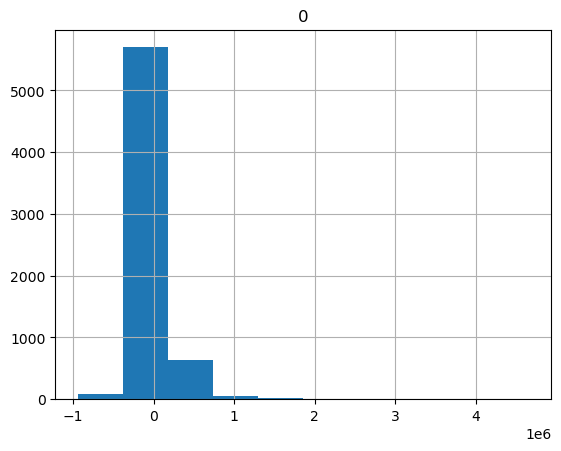

In [127]:
 #Grafico del histograma de residuales para la base de prueba
df=pd.DataFrame(Resid)
df.hist()

La selección de variables fue crucial para alcanzar un valor de R2 de 66%. Reduciendo la varianza con la inclusión de variables completamente relacionadas que pueden forzar el modelo. Se comprobó por ambos metodos que llegamos a la misma respuesta.